# Prelucrarea datelor de intrare

* Ce tip de date avem?
Imagini .jpg etichetate pe 4 clase:
    - acnes: coșuri, pustule
    - blackheads: puncte negre
    - darkspots: pete pigmentare
    - wrinkles: riduri

Prima sectiune de cod realizeaza o analiza preliminara a datelor pentru intelegerea continutului de date si structura dataset-ului nostru. Scopul este sa verificam cate imagini avem pentru fiecare categorie (acnee,puncte negre,pete pigmentare,riduri) si sa analizam dimensiunile imaginilor.

In [2]:
import os
import cv2

base_path = "SkinMate-Dataset"
categories = ["acnes", "blackheads", "darkspots", "wrinkles"]
image_stats = {}

for category in categories:
    path = os.path.join(base_path, category)
    images = os.listdir(path)
    image_stats[category] = {"count": len(images), "sizes": []}
    
    for img_name in images[:5]:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            height, weight, _ = img.shape
            image_stats[category]["sizes"].append((weight, height))

for cat, stats in image_stats.items():
    print(f"{cat.upper()}: {stats['count']} imagini")
    print(f"Dimensiuni (w,h) exemple: {stats['sizes']}")


ACNES: 250 imagini
Dimensiuni (w,h) exemple: [(500, 555), (500, 555), (500, 555), (500, 555), (500, 555)]
BLACKHEADS: 250 imagini
Dimensiuni (w,h) exemple: [(468, 263), (468, 263), (468, 263), (468, 263), (480, 360)]
DARKSPOTS: 250 imagini
Dimensiuni (w,h) exemple: [(195, 259), (244, 206), (119, 150), (193, 261), (300, 168)]
WRINKLES: 250 imagini
Dimensiuni (w,h) exemple: [(301, 167), (225, 225), (111, 219), (270, 186), (358, 141)]


Urmeaza o vizualizarea a histogramei culorilor pentru imaginile noastre si distributia in functie de dimensiuniile acestora

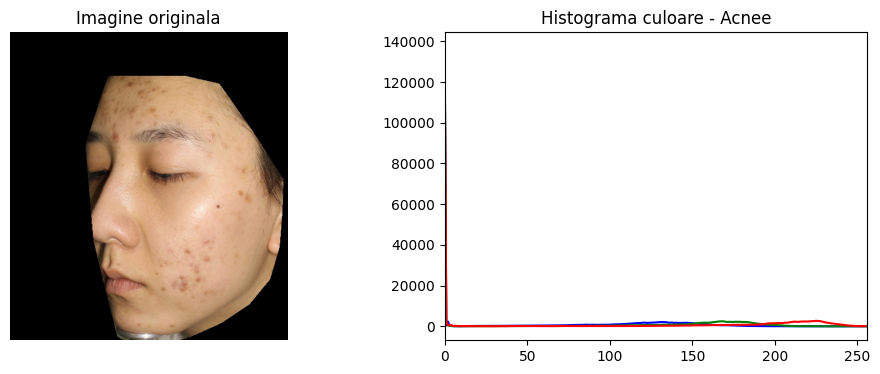

In [3]:
import matplotlib.pyplot as plt

def plot_histogram(img, title):
    color = ('b','g','r')
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title("Imagine originala")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    for i,col in enumerate(color):
        histr = cv2.calcHist([img],[i],None,[256],[0,256])
        plt.plot(histr, color=col)
        plt.xlim([0,256])
    plt.title(title)
    plt.show()

sample_image = cv2.imread('SkinMate-Dataset/acnes/levle1_56.jpg')
plot_histogram(sample_image, "Histograma culoare - Acnee")


* Normalizarea pozelor in functie de dimensiunea lor

In [4]:
import numpy as np

def preprocess_and_save(base_path, out_path, categories):
    os.makedirs(out_path, exist_ok=True)
    
    for category in categories:
        cat_path = os.path.join(base_path, category)
        save_cat_path = os.path.join(out_path, category)
        os.makedirs(save_cat_path, exist_ok=True)

        for img_name in os.listdir(cat_path):
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, (224, 224))
            img = img / 255.0
            npy_name = os.path.splitext(img_name)[0] + ".npy"
            save_path = os.path.join(save_cat_path, npy_name)
            np.save(save_path, img)

    print("Toate imaginile au fost procesate si salvate ca .npy in "+out_path)

base_path = "SkinMate-Dataset"
out_path = "Processed-Dataset"
categories = ["acnes", "blackheads", "darkspots", "wrinkles"]
preprocess_and_save(base_path, out_path, categories)


Toate imaginile au fost procesate si salvate ca .npy in Processed-Dataset


Facem un plot pentru a vizualiza o imagine originala vs prelucrata

Categoria: acnes | Imagine: levle2_170.jpg


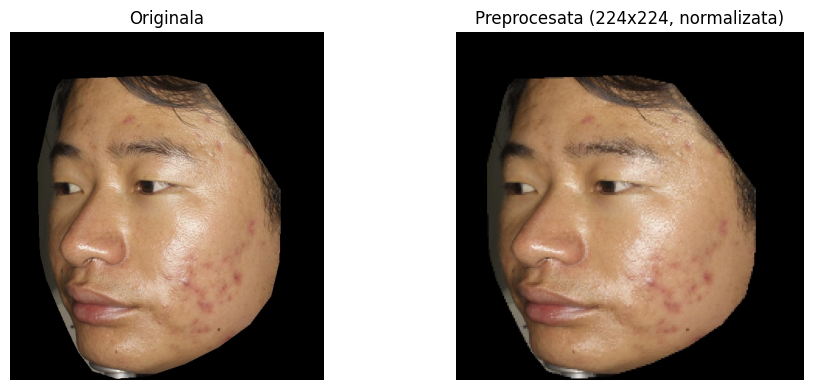

Categoria: blackheads | Imagine: 00000195.jpg


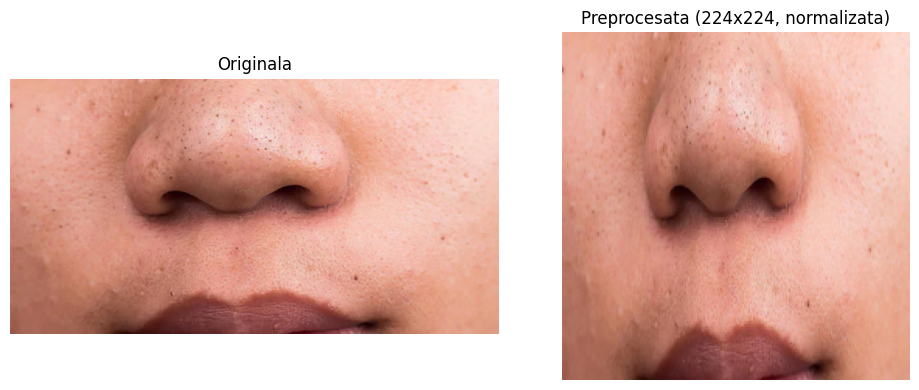

Categoria: darkspots | Imagine: efd4b0bd-4be5-4dfb-b118-71de0cde6b7c - Copy.jpg


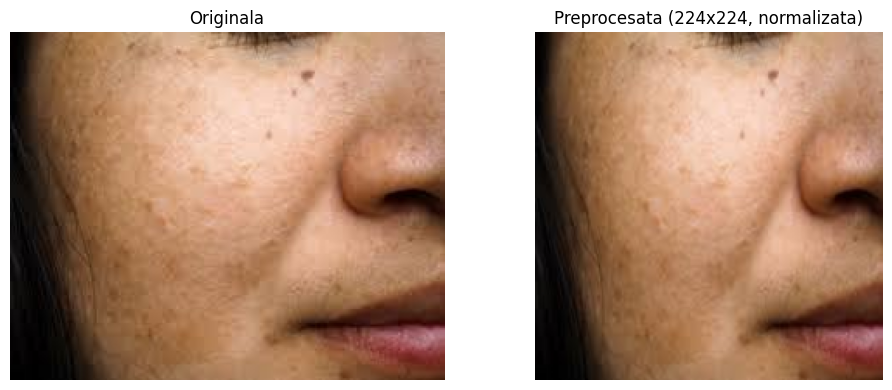

Categoria: wrinkles | Imagine: 115.jpg


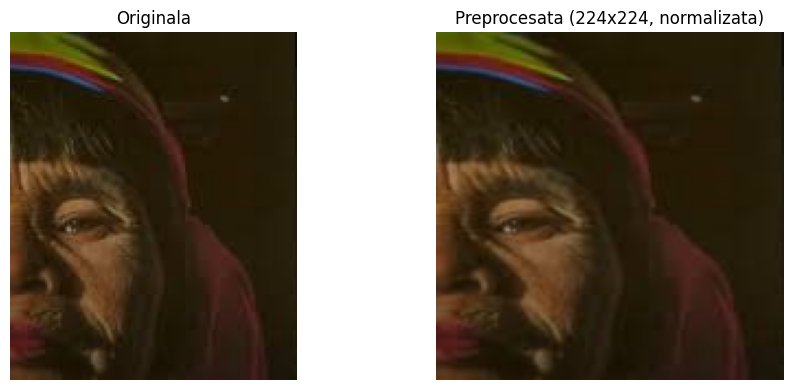

In [5]:
import random

def preprocess(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Imaginea nu a putut fi incarcata: {img_path}")
    img = cv2.resize(img, (224, 224))
    img = img.astype('float32') / 255.0
    return img

def show_original_vs_preprocessed(img_path):
    orig = cv2.imread(img_path)
    pre = preprocess(img_path)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Originala")
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor((pre * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    axs[1].set_title("Preprocesata (224x224, normalizata)")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

base_path = "SkinMate-Dataset"
categories = ["acnes", "blackheads", "darkspots", "wrinkles"]

for cat in categories:
    cat_path = os.path.join(base_path, cat)
    img_list = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_list:
        print(f"Nu exista imagini in folderul {cat}")
        continue
    img_name = random.choice(img_list)
    img_path = os.path.join(cat_path, img_name)
    print(f"Categoria: {cat} | Imagine: {img_name}")
    show_original_vs_preprocessed(img_path)


Cream o baza de date pentru a tine cont de categoriile pe care le avem la dispozitie

In [6]:
import os
import pandas as pd

processed_path = "Processed-Dataset"
categories = ["acnes", "blackheads", "darkspots", "wrinkles"]
data = []
for label in categories:
    folder = os.path.join(processed_path, label)
    for file in os.listdir(folder):
        if file.endswith(".npy"):
            full_path = os.path.join(folder, file)
            data.append([full_path, label])

df = pd.DataFrame(data, columns=["file_path", "label"])
df.to_csv("dataset.csv", index=False)
print("Fisierul dataset.csv a fost creat cu succes!")
df.head()


Fisierul dataset.csv a fost creat cu succes!


,file_path,label
0,Processed-Dataset\acnes\levle1_483.npy,acnes
1,Processed-Dataset\acnes\levle1_484.npy,acnes
2,Processed-Dataset\acnes\levle1_485.npy,acnes
3,Processed-Dataset\acnes\levle1_486.npy,acnes
4,Processed-Dataset\acnes\levle1_51.npy,acnes


Impartirea datelor in antrenament, evaluare si test

In [7]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['label'], random_state=42)

train_df.to_csv("data2/train.csv", index=False)
val_df.to_csv("data2/val.csv", index=False)
test_df.to_csv("data2/test.csv", index=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 640 | Val: 160 | Test: 200


Verificam distributia pentru fiecare set de date


Train set:
label
acnes         160
blackheads    160
darkspots     160
wrinkles      160
Name: count, dtype: int64


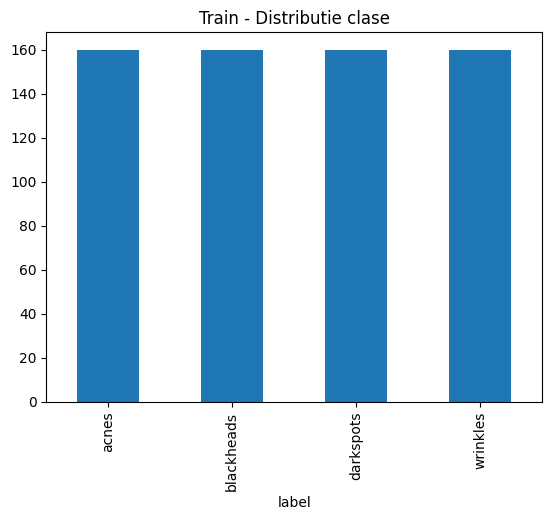


Validation set:
label
darkspots     40
blackheads    40
wrinkles      40
acnes         40
Name: count, dtype: int64


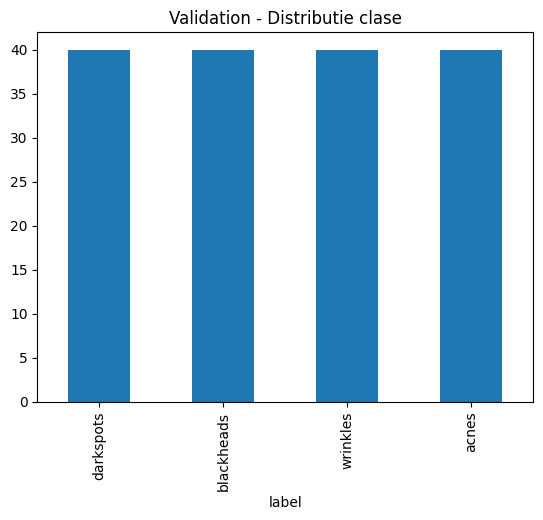


Test set:
label
darkspots     50
blackheads    50
wrinkles      50
acnes         50
Name: count, dtype: int64


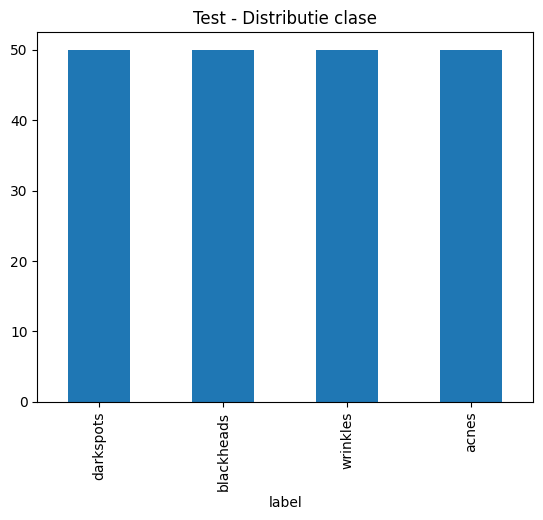

In [8]:
import matplotlib.pyplot as plt

for name, subset in zip(["Train", "Validation", "Test"], [train_df, val_df, test_df]):
    print(f"\n{name} set:")
    print(subset['label'].value_counts())
    subset['label'].value_counts().plot(kind='bar', title=f"{name} - Distributie clase")
    plt.show()